# Day 2: PySpark DataFrames – Practical Data Processing
🕐 **Total: 2 hours**

| Topic | Notes |
|-------|-------|
|  Exploring DataFrames | .show(), .printSchema(), .describe() |
|  Selecting/Filtering/Sorting | .select(), .filter(), .orderBy() |
|  Column Operations |  Using col(), withColumn() |
|  Math, String, Date Functions | Hands-on functions |
|  Grouping and Aggregation |  .groupBy(), .agg() |
|  Join Operations |  Inner, left, etc. |
|  Problem Statements |  Solve 2–3 live problems from real datasets |


---

### Exploring Dataframes

In [2]:
from pyspark.sql import SparkSession

spark=SparkSession.builder \
    .appName("Spark SQL Example") \
    .getOrCreate()

# Load data from a CSV file

user_profiles=spark.read.csv("file:///C:/docs/user_profiles.csv", header=True, inferSchema=True)

# Load Json file data into a DataFrame

posts_and_comments = spark.read.json("file:///C:/docs/posts_and_comments.json", multiLine=True)

# show
user_profiles.show(5)
posts_and_comments.show(5)

+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+
|user_id|         name|               email|gender|date_of_birth|country|signup_date|is_active|followers_count|
+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+
|    101|     John Doe|john.doe@example.com|  Male|   1990-05-15|    USA| 2020-01-10|     true|           1500|
|      2|   Jane Smith|jane.smith@exampl...|Female|   1985-08-20| Canada| 2019-03-15|     true|           2300|
|      3| Mark Johnson|mark.johnson@exam...|  Male|   1992-11-05|     UK| 2021-07-01|    false|            800|
|      4|  Emily Davis|emily.davis@examp...|Female|   1995-02-25|  India| 2020-05-20|     true|           1200|
|      5|Michael Brown|michael.brown@exa...|  Male|   1988-09-12|    USA| 2018-11-30|     true|           4500|
+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------

In [3]:
#PrintSchema 

user_profiles.printSchema()
posts_and_comments.printSchema()

root
 |-- user_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- date_of_birth: date (nullable = true)
 |-- country: string (nullable = true)
 |-- signup_date: date (nullable = true)
 |-- is_active: boolean (nullable = true)
 |-- followers_count: integer (nullable = true)

root
 |-- comments: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- comment_id: string (nullable = true)
 |    |    |-- comment_text: string (nullable = true)
 |    |    |-- created_at: string (nullable = true)
 |    |    |-- user_id: string (nullable = true)
 |-- created_at: string (nullable = true)
 |-- hashtags: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- post_content: string (nullable = true)
 |-- post_id: string (nullable = true)
 |-- user_id: string (nullable = true)



In [4]:
##describe
user_profiles.describe().show()

#dislpay 
#display(): Renders DataFrame in a visually interactive table (often used in Databricks).

+-------+-----------------+--------------+--------------------+------+---------+-----------------+
|summary|          user_id|          name|               email|gender|  country|  followers_count|
+-------+-----------------+--------------+--------------------+------+---------+-----------------+
|  count|               50|            50|                  50|    50|       50|               50|
|   mean|             27.5|          NULL|                NULL|  NULL|     NULL|           2069.0|
| stddev|17.67766952966368|          NULL|                NULL|  NULL|     NULL|1063.393201991068|
|    min|                2| Abigail Evans|abigail.evans@exa...|Female|Australia|              600|
|    max|              101|William Nelson|william.nelson@ex...|  Male|      USA|             5000|
+-------+-----------------+--------------+--------------------+------+---------+-----------------+



#### For Selecting columns we use Select

### Refering to Columns in pyspark 

1. By using the column name as Strings -> Most Simple
2. Columns as attributes of dataframes -> Code Readable
3. Using col() function -> Dynamic referencing
4. Rreference columns using dictionary-style syntax. -> Dealing with columns with space or special characters 
5. Using lit() to Create columns -> Adding constanr values to dataframe 

In [5]:
user_profiles.select("user_id", "name").show(5)

+-------+-------------+
|user_id|         name|
+-------+-------------+
|    101|     John Doe|
|      2|   Jane Smith|
|      3| Mark Johnson|
|      4|  Emily Davis|
|      5|Michael Brown|
+-------+-------------+
only showing top 5 rows



In [6]:
user_profiles.select(user_profiles.user_id).show(5)
user_profiles.select("user_id").show(5)

+-------+
|user_id|
+-------+
|    101|
|      2|
|      3|
|      4|
|      5|
+-------+
only showing top 5 rows

+-------+
|user_id|
+-------+
|    101|
|      2|
|      3|
|      4|
|      5|
+-------+
only showing top 5 rows



In [7]:
user_profiles.select("*").show(5)

+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+
|user_id|         name|               email|gender|date_of_birth|country|signup_date|is_active|followers_count|
+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+
|    101|     John Doe|john.doe@example.com|  Male|   1990-05-15|    USA| 2020-01-10|     true|           1500|
|      2|   Jane Smith|jane.smith@exampl...|Female|   1985-08-20| Canada| 2019-03-15|     true|           2300|
|      3| Mark Johnson|mark.johnson@exam...|  Male|   1992-11-05|     UK| 2021-07-01|    false|            800|
|      4|  Emily Davis|emily.davis@examp...|Female|   1995-02-25|  India| 2020-05-20|     true|           1200|
|      5|Michael Brown|michael.brown@exa...|  Male|   1988-09-12|    USA| 2018-11-30|     true|           4500|
+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------

In [8]:
from pyspark.sql.functions import col
temp = "country"
user_profiles.select(col("user_id"), temp, col("email")).show(5)

+-------+-------+--------------------+
|user_id|country|               email|
+-------+-------+--------------------+
|    101|    USA|john.doe@example.com|
|      2| Canada|jane.smith@exampl...|
|      3|     UK|mark.johnson@exam...|
|      4|  India|emily.davis@examp...|
|      5|    USA|michael.brown@exa...|
+-------+-------+--------------------+
only showing top 5 rows



In [9]:
from pyspark.sql.functions import col

temp=["post_id","comments","post_content"]

posts_and_comments.select(*(temp)).show(5)

+-------+--------------------+--------------------+
|post_id|            comments|        post_content|
+-------+--------------------+--------------------+
|    101|[{201, Great post...|Exploring the wor...|
|    102|[{203, Absolutely...|Learning PySpark ...|
|    103|[{205, Congrats! ...|Just finished a S...|
|    104|[{206, Agreed!, 2...|DataFrames make l...|
|    105|[{207, Nice tips!...|Aggregation and g...|
+-------+--------------------+--------------------+



In [10]:
posts_and_comments.show()

+--------------------+-------------------+--------------------+--------------------+-------+-------+
|            comments|         created_at|            hashtags|        post_content|post_id|user_id|
+--------------------+-------------------+--------------------+--------------------+-------+-------+
|[{201, Great post...|2023-10-01T10:00:00|[#BigData, #Analy...|Exploring the wor...|    101|      1|
|[{203, Absolutely...|2023-10-02T12:00:00|[#PySpark, #BigData]|Learning PySpark ...|    102|      2|
|[{205, Congrats! ...|2023-10-03T09:30:00|[#SparkSQL, #Data...|Just finished a S...|    103|      3|
|[{206, Agreed!, 2...|2023-10-04T14:00:00|[#DataFrames, #Py...|DataFrames make l...|    104|      4|
|[{207, Nice tips!...|2023-10-05T16:00:00|[#Aggregation, #G...|Aggregation and g...|    105|      5|
+--------------------+-------------------+--------------------+--------------------+-------+-------+



In [11]:
print(posts_and_comments.count())

5


In [12]:
posts_and_comments.show(truncate=False)

+---------------------------------------------------------------------------------------------------------------+-------------------+---------------------------------+----------------------------------------------+-------+-------+
|comments                                                                                                       |created_at         |hashtags                         |post_content                                  |post_id|user_id|
+---------------------------------------------------------------------------------------------------------------+-------------------+---------------------------------+----------------------------------------------+-------+-------+
|[{201, Great post!, 2023-10-01T10:05:00, 2}, {202, Very informative., 2023-10-01T10:10:00, 3}]                 |2023-10-01T10:00:00|[#BigData, #Analytics]           |Exploring the world of big data!              |101    |1      |
|[{203, Absolutely, it's powerful., 2023-10-02T12:15:00, 1}, {204, Thanks fo

### Selecting columns in pyspark

1. `Select ()`
2. `col ()`
3. `withColumn()` -> Add new Column 
4. `alias ()` 
5. `withColumnRenamed ()` -> Renaming the column of dataframe
6. Dynamically selecting columns
7. drop()
8. expr()
9. Working with nested Structures


In [13]:
from pyspark.sql.functions import col
user_profiles.select(col("user_id"), col("name").alias("user_name"), col("email").alias("user_email"), col("country")).show(5)

+-------+-------------+--------------------+-------+
|user_id|    user_name|          user_email|country|
+-------+-------------+--------------------+-------+
|    101|     John Doe|john.doe@example.com|    USA|
|      2|   Jane Smith|jane.smith@exampl...| Canada|
|      3| Mark Johnson|mark.johnson@exam...|     UK|
|      4|  Emily Davis|emily.davis@examp...|  India|
|      5|Michael Brown|michael.brown@exa...|    USA|
+-------+-------------+--------------------+-------+
only showing top 5 rows



In [14]:
from pyspark.sql.functions import split,col
user_profiles=user_profiles.withColumn("last_name",split(col("name"), " ")[1])
user_profiles.show(5)

+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+---------+
|user_id|         name|               email|gender|date_of_birth|country|signup_date|is_active|followers_count|last_name|
+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+---------+
|    101|     John Doe|john.doe@example.com|  Male|   1990-05-15|    USA| 2020-01-10|     true|           1500|      Doe|
|      2|   Jane Smith|jane.smith@exampl...|Female|   1985-08-20| Canada| 2019-03-15|     true|           2300|    Smith|
|      3| Mark Johnson|mark.johnson@exam...|  Male|   1992-11-05|     UK| 2021-07-01|    false|            800|  Johnson|
|      4|  Emily Davis|emily.davis@examp...|Female|   1995-02-25|  India| 2020-05-20|     true|           1200|    Davis|
|      5|Michael Brown|michael.brown@exa...|  Male|   1988-09-12|    USA| 2018-11-30|     true|           4500|    Brown|
+-------+-------------+-

In [15]:
user_profiles.printSchema()

root
 |-- user_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- date_of_birth: date (nullable = true)
 |-- country: string (nullable = true)
 |-- signup_date: date (nullable = true)
 |-- is_active: boolean (nullable = true)
 |-- followers_count: integer (nullable = true)
 |-- last_name: string (nullable = true)



In [16]:
user_profiles=user_profiles.withColumnRenamed("name","full_name")
user_profiles.show(5)

+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+---------+
|user_id|    full_name|               email|gender|date_of_birth|country|signup_date|is_active|followers_count|last_name|
+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+---------+
|    101|     John Doe|john.doe@example.com|  Male|   1990-05-15|    USA| 2020-01-10|     true|           1500|      Doe|
|      2|   Jane Smith|jane.smith@exampl...|Female|   1985-08-20| Canada| 2019-03-15|     true|           2300|    Smith|
|      3| Mark Johnson|mark.johnson@exam...|  Male|   1992-11-05|     UK| 2021-07-01|    false|            800|  Johnson|
|      4|  Emily Davis|emily.davis@examp...|Female|   1995-02-25|  India| 2020-05-20|     true|           1200|    Davis|
|      5|Michael Brown|michael.brown@exa...|  Male|   1988-09-12|    USA| 2018-11-30|     true|           4500|    Brown|
+-------+-------------+-

In [17]:
user_profiles.printSchema()

root
 |-- user_id: integer (nullable = true)
 |-- full_name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- date_of_birth: date (nullable = true)
 |-- country: string (nullable = true)
 |-- signup_date: date (nullable = true)
 |-- is_active: boolean (nullable = true)
 |-- followers_count: integer (nullable = true)
 |-- last_name: string (nullable = true)



In [18]:
req=["full_name","last_name","email"]
user_profiles.select(*(req)).show(5)

+-------------+---------+--------------------+
|    full_name|last_name|               email|
+-------------+---------+--------------------+
|     John Doe|      Doe|john.doe@example.com|
|   Jane Smith|    Smith|jane.smith@exampl...|
| Mark Johnson|  Johnson|mark.johnson@exam...|
|  Emily Davis|    Davis|emily.davis@examp...|
|Michael Brown|    Brown|michael.brown@exa...|
+-------------+---------+--------------------+
only showing top 5 rows



In [19]:
user_profiles=user_profiles.drop("last_name")
print(user_profiles.show())
user_profiles.printSchema()

+-------+---------------+--------------------+------+-------------+---------+-----------+---------+---------------+
|user_id|      full_name|               email|gender|date_of_birth|  country|signup_date|is_active|followers_count|
+-------+---------------+--------------------+------+-------------+---------+-----------+---------+---------------+
|    101|       John Doe|john.doe@example.com|  Male|   1990-05-15|      USA| 2020-01-10|     true|           1500|
|      2|     Jane Smith|jane.smith@exampl...|Female|   1985-08-20|   Canada| 2019-03-15|     true|           2300|
|      3|   Mark Johnson|mark.johnson@exam...|  Male|   1992-11-05|       UK| 2021-07-01|    false|            800|
|      4|    Emily Davis|emily.davis@examp...|Female|   1995-02-25|    India| 2020-05-20|     true|           1200|
|      5|  Michael Brown|michael.brown@exa...|  Male|   1988-09-12|      USA| 2018-11-30|     true|           4500|
|      6|   Sarah Wilson|sarah.wilson@exam...|Female|   1993-06-18|Austr

In [20]:
print(type(user_profiles))

<class 'pyspark.sql.dataframe.DataFrame'>


In [21]:
user_profiles.printSchema()

root
 |-- user_id: integer (nullable = true)
 |-- full_name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- date_of_birth: date (nullable = true)
 |-- country: string (nullable = true)
 |-- signup_date: date (nullable = true)
 |-- is_active: boolean (nullable = true)
 |-- followers_count: integer (nullable = true)



In [22]:
temp=user_profiles.select("user_id")
temp.show(5)

+-------+
|user_id|
+-------+
|    101|
|      2|
|      3|
|      4|
|      5|
+-------+
only showing top 5 rows



In [23]:
from pyspark.sql.functions import expr

# Selecting with expressions
selected_df = user_profiles.select(expr("user_id + 1 AS new_user_id"),"*")
selected_df = user_profiles.select("*",expr("followers_count + 100 AS updated_follower_count") )

selected_df.show(5)

+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+----------------------+
|user_id|    full_name|               email|gender|date_of_birth|country|signup_date|is_active|followers_count|updated_follower_count|
+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+----------------------+
|    101|     John Doe|john.doe@example.com|  Male|   1990-05-15|    USA| 2020-01-10|     true|           1500|                  1600|
|      2|   Jane Smith|jane.smith@exampl...|Female|   1985-08-20| Canada| 2019-03-15|     true|           2300|                  2400|
|      3| Mark Johnson|mark.johnson@exam...|  Male|   1992-11-05|     UK| 2021-07-01|    false|            800|                   900|
|      4|  Emily Davis|emily.davis@examp...|Female|   1995-02-25|  India| 2020-05-20|     true|           1200|                  1300|
|      5|Michael Brown|michael.brown@exa...|  Male|   1

### Filtering Data 

1. filter and where -> Take column or expression as conditions 
2. Combinig conditions with Logical Operators
    i) and `(&)`
    ii) or `(|)`
    iii) not `(!)`
3. Filtering String conditions
4. isin() method
5. isNull() or isNotNull()

In [ ]:
user_profiles.filter("date_of_birth > '1997-01-01'").show()
# user_profiles.where("date_of_birth > '1997-01-01'").show(5)

+-------+-------------------+--------------------+------+-------------+---------+-----------+---------+---------------+
|user_id|          full_name|               email|gender|date_of_birth|  country|signup_date|is_active|followers_count|
+-------+-------------------+--------------------+------+-------------+---------+-----------+---------+---------------+
|      8|    Sophia Martinez|sophia.martinez@e...|Female|   1997-12-01|  Germany| 2020-12-10|     true|           1800|
|     14|         Ava Wilson|ava.wilson@exampl...|Female|   1998-03-30|Australia| 2021-05-10|     true|           1600|
|     24|       Evelyn Baker|evelyn.baker@exam...|Female|   1997-09-13|   Canada| 2021-06-06|     true|           1400|
|     30|      Harper Turner|harper.turner@exa...|Female|   1998-06-09|Australia| 2019-07-14|     true|           1550|
|     38|       Emily Morris|emily.morris@exam...|Female|   1997-04-11|Australia| 2020-09-09|     true|           1650|
|     48|Penelope Richardson|penelope.ri

In [ ]:
user_profiles.filter((col("gender") == "Female") | (col("followers_count") > 3000)).show()

+-------+---------------+--------------------+------+-------------+---------+-----------+---------+---------------+
|user_id|      full_name|               email|gender|date_of_birth|  country|signup_date|is_active|followers_count|
+-------+---------------+--------------------+------+-------------+---------+-----------+---------+---------------+
|      2|     Jane Smith|jane.smith@exampl...|Female|   1985-08-20|   Canada| 2019-03-15|     true|           2300|
|      4|    Emily Davis|emily.davis@examp...|Female|   1995-02-25|    India| 2020-05-20|     true|           1200|
|      5|  Michael Brown|michael.brown@exa...|  Male|   1988-09-12|      USA| 2018-11-30|     true|           4500|
|      6|   Sarah Wilson|sarah.wilson@exam...|Female|   1993-06-18|Australia| 2021-01-15|    false|            600|
|      7|      David Lee|david.lee@example...|  Male|   1990-03-10|      USA| 2019-09-25|     true|           3200|
|      8|Sophia Martinez|sophia.martinez@e...|Female|   1997-12-01|  Ger

In [26]:
user_profiles.filter (~(col("gender") == "Female") & (col("followers_count") > 3000)).show()

+-------+------------------+--------------------+------+-------------+-------+-----------+---------+---------------+
|user_id|         full_name|               email|gender|date_of_birth|country|signup_date|is_active|followers_count|
+-------+------------------+--------------------+------+-------------+-------+-----------+---------+---------------+
|      5|     Michael Brown|michael.brown@exa...|  Male|   1988-09-12|    USA| 2018-11-30|     true|           4500|
|      7|         David Lee|david.lee@example...|  Male|   1990-03-10|    USA| 2019-09-25|     true|           3200|
|     11|     Robert Downey|robert.downey@exa...|  Male|   1980-01-01|    USA| 2017-08-15|     true|           5000|
|     23|    Benjamin Adams|benjamin.adams@ex...|  Male|   1990-04-21|    USA| 2019-08-08|     true|           3100|
|     27|    Henry Mitchell|henry.mitchell@ex...|  Male|   1992-02-02|    USA| 2019-05-15|     true|           3700|
|     35|    Joseph Edwards|joseph.edwards@ex...|  Male|   1990-

In [27]:
user_profiles.filter("country = 'USA' and gender='Male'").show()
user_profiles.filter ((col("gender") == "Male") & (col("country") == "USA")).show()

+-------+------------------+--------------------+------+-------------+-------+-----------+---------+---------------+
|user_id|         full_name|               email|gender|date_of_birth|country|signup_date|is_active|followers_count|
+-------+------------------+--------------------+------+-------------+-------+-----------+---------+---------------+
|    101|          John Doe|john.doe@example.com|  Male|   1990-05-15|    USA| 2020-01-10|     true|           1500|
|      5|     Michael Brown|michael.brown@exa...|  Male|   1988-09-12|    USA| 2018-11-30|     true|           4500|
|      7|         David Lee|david.lee@example...|  Male|   1990-03-10|    USA| 2019-09-25|     true|           3200|
|     11|     Robert Downey|robert.downey@exa...|  Male|   1980-01-01|    USA| 2017-08-15|     true|           5000|
|     15|        Noah Davis|noah.davis@exampl...|  Male|   1993-07-25|    USA| 2020-09-15|     true|           2800|
|     23|    Benjamin Adams|benjamin.adams@ex...|  Male|   1990-

In [28]:
user_profiles.filter(user_profiles.country.isin("USA", "Canada")).show(5)

+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+
|user_id|    full_name|               email|gender|date_of_birth|country|signup_date|is_active|followers_count|
+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+
|    101|     John Doe|john.doe@example.com|  Male|   1990-05-15|    USA| 2020-01-10|     true|           1500|
|      2|   Jane Smith|jane.smith@exampl...|Female|   1985-08-20| Canada| 2019-03-15|     true|           2300|
|      5|Michael Brown|michael.brown@exa...|  Male|   1988-09-12|    USA| 2018-11-30|     true|           4500|
|      7|    David Lee|david.lee@example...|  Male|   1990-03-10|    USA| 2019-09-25|     true|           3200|
|     11|Robert Downey|robert.downey@exa...|  Male|   1980-01-01|    USA| 2017-08-15|     true|           5000|
+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------

isNull , isNotNull

statsWith, endsWith

like , rlike 

### Grouping Data 

- groupBy -> groups rows based on specified columns and allows for aggregate functions to be applied.
- Aggregation functions
    - pyspark.sql.functions module 
    - import functions as F
- Common Aggregate functions 
    - count ()
    - sum ()
    - avg ()
    - min() and max() 
    - countDistinct()

- Using agg() function


In [29]:
user_profiles.groupBy("country").count().show()

+---------+-----+
|  country|count|
+---------+-----+
|  Germany|    5|
|   France|    5|
|    India|    7|
|      USA|   13|
|       UK|    7|
|   Canada|    7|
|Australia|    6|
+---------+-----+



In [30]:
from pyspark.sql import functions as F

user_profiles.groupBy("country").agg(
    F.avg("followers_count").alias("average_followers"),
    F.count("user_id").alias("usersss_count"),
    F.max("followers_count").alias("max_followers")
).show()

+---------+------------------+-------------+-------------+
|  country| average_followers|usersss_count|max_followers|
+---------+------------------+-------------+-------------+
|  Germany|            1840.0|            5|         1950|
|   France|             880.0|            5|          950|
|    India| 2064.285714285714|            7|         2600|
|      USA| 3369.230769230769|           13|         5000|
|       UK|1121.4285714285713|            7|         3300|
|   Canada| 2042.857142857143|            7|         2300|
|Australia|            1575.0|            6|         2200|
+---------+------------------+-------------+-------------+



### Joining the data
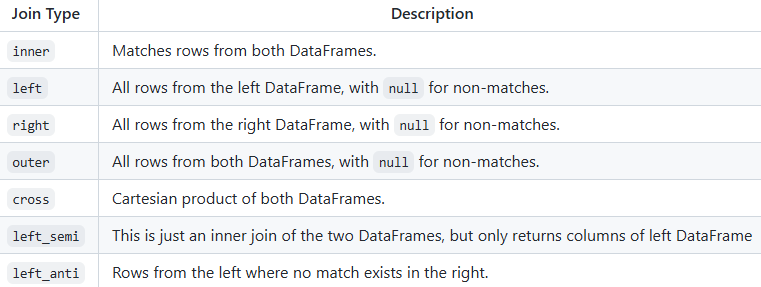

Syntax for joining goes as:

DataFrame1.join(Dataframe2, on="column", how="type")

In [43]:
user_profiles.show(5)
posts_and_comments.show(5)

+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+----------+-----------+------------+
|user_id|    full_name|               email|gender|date_of_birth|country|signup_date|is_active|followers_count|birth_year|birth_month|day_of_month|
+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+----------+-----------+------------+
|    101|     John Doe|john.doe@example.com|  Male|   1990-05-15|    USA| 2020-01-10|     true|           1500|      1990|          5|          15|
|      2|   Jane Smith|jane.smith@exampl...|Female|   1985-08-20| Canada| 2019-03-15|     true|           2300|      1985|          8|          20|
|      3| Mark Johnson|mark.johnson@exam...|  Male|   1992-11-05|     UK| 2021-07-01|    false|            800|      1992|         11|           5|
|      4|  Emily Davis|emily.davis@examp...|Female|   1995-02-25|  India| 2020-05-20|     true|           1200| 

In [32]:
result = user_profiles.join(posts_and_comments, on="user_id", how="inner")
result.show()

+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+--------------------+-------------------+--------------------+--------------------+-------+
|user_id|    full_name|               email|gender|date_of_birth|country|signup_date|is_active|followers_count|            comments|         created_at|            hashtags|        post_content|post_id|
+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+--------------------+-------------------+--------------------+--------------------+-------+
|      2|   Jane Smith|jane.smith@exampl...|Female|   1985-08-20| Canada| 2019-03-15|     true|           2300|[{203, Absolutely...|2023-10-02T12:00:00|[#PySpark, #BigData]|Learning PySpark ...|    102|
|      3| Mark Johnson|mark.johnson@exam...|  Male|   1992-11-05|     UK| 2021-07-01|    false|            800|[{205, Congrats! ...|2023-10-03T09:30:00|[#SparkSQL, #Data...|Just finished a

In [33]:
result = user_profiles.join(posts_and_comments, on="user_id", how="left")
result.show(10)

+-------+---------------+--------------------+------+-------------+---------+-----------+---------+---------------+--------------------+-------------------+--------------------+--------------------+-------+
|user_id|      full_name|               email|gender|date_of_birth|  country|signup_date|is_active|followers_count|            comments|         created_at|            hashtags|        post_content|post_id|
+-------+---------------+--------------------+------+-------------+---------+-----------+---------+---------------+--------------------+-------------------+--------------------+--------------------+-------+
|    101|       John Doe|john.doe@example.com|  Male|   1990-05-15|      USA| 2020-01-10|     true|           1500|                NULL|               NULL|                NULL|                NULL|   NULL|
|      2|     Jane Smith|jane.smith@exampl...|Female|   1985-08-20|   Canada| 2019-03-15|     true|           2300|[{203, Absolutely...|2023-10-02T12:00:00|[#PySpark, #BigD

##### Joining 2 Dataframes, Selecting all columns from the first and some columns from the second

In [45]:
result_df = user_profiles.join(posts_and_comments, on = ["user_id"], how="inner") \
    .select(
    user_profiles["*"],  # All columns from sales_df
    posts_and_comments["post_id"].alias("postMade")  # Specific column from customers_df
).show()


+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+----------+-----------+------------+--------+
|user_id|    full_name|               email|gender|date_of_birth|country|signup_date|is_active|followers_count|birth_year|birth_month|day_of_month|postMade|
+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+----------+-----------+------------+--------+
|      2|   Jane Smith|jane.smith@exampl...|Female|   1985-08-20| Canada| 2019-03-15|     true|           2300|      1985|          8|          20|     102|
|      3| Mark Johnson|mark.johnson@exam...|  Male|   1992-11-05|     UK| 2021-07-01|    false|            800|      1992|         11|           5|     103|
|      4|  Emily Davis|emily.davis@examp...|Female|   1995-02-25|  India| 2020-05-20|     true|           1200|      1995|          2|          25|     104|
|      5|Michael Brown|michael.brown@exa...|  Male|   1988

In [35]:
print(type(user_profiles["date_of_birth"]))
temp= user_profiles.select("date_of_birth").take(1)
print(type(temp[0].date_of_birth))

<class 'pyspark.sql.column.Column'>
<class 'datetime.date'>


#### Date and time functions

1. Parsing and Converting dates
    - to_date(column,format) : Converts a string to a date using the specified format.
    - to_timestamp(column,format) : Converts a string to a timestamp.
2. Formatting dates
    - date_format(date, format) : Formats a date into a string with the specified pattern (e.g., "yyyy-M-d", "d/M/yyyy").
3. Current Date and Time
    - current_date(): Returns the current date.
    - current_timestamp(): Returns the current timestamp.
4. Extracting Parts of Dates
    - year(): Extracts the year from a date.
    - month(): Extracts the month.
    - dayofmonth(): Extracts the day of the month.
    - dayofweek(): Returns the day of the week as an integer (1 = - Sunday, 7 = Saturday).
    - weekofyear(): Extracts the week number of the year.
5. Date Arithematic
    - datediff(end, start): Returns the number of days between two dates.
    - add_months(date, numMonths): Adds or subtracts months from a date.
    - date_add(date, days): Adds a specific number of days to a date.
    - date_sub(date, days): Subtracts a specific number of days from a date.
6. Truncating Dates
    - trunc(date, format): Truncates a date to the specified format ("year", "month", etc.).
    - date_trunc(format, timestamp): Truncates a timestamp to the specified unit ("hour", "day", "month", etc.).

In [ ]:
# extracting year from date_of_birth
from pyspark.sql.functions import year, month, dayofmonth
user_profiles = user_profiles.withColumn("birth_year", year(col("date_of_birth")))
user_profiles = user_profiles.withColumn("birth_month", month(col("date_of_birth")))
user_profiles = user_profiles.withColumn("day_of_month", dayofmonth(col("date_of_birth")))


user_profiles.select("user_id", user_profiles["full_name"].alias("name"), "birth_year", "birth_month", "day_of_month").show(5)

+-------+-------------+----------+-----------+------------+
|user_id|         name|birth_year|birth_month|day_of_month|
+-------+-------------+----------+-----------+------------+
|    101|     John Doe|      1990|          5|          15|
|      2|   Jane Smith|      1985|          8|          20|
|      3| Mark Johnson|      1992|         11|           5|
|      4|  Emily Davis|      1995|          2|          25|
|      5|Michael Brown|      1988|          9|          12|
+-------+-------------+----------+-----------+------------+
only showing top 5 rows



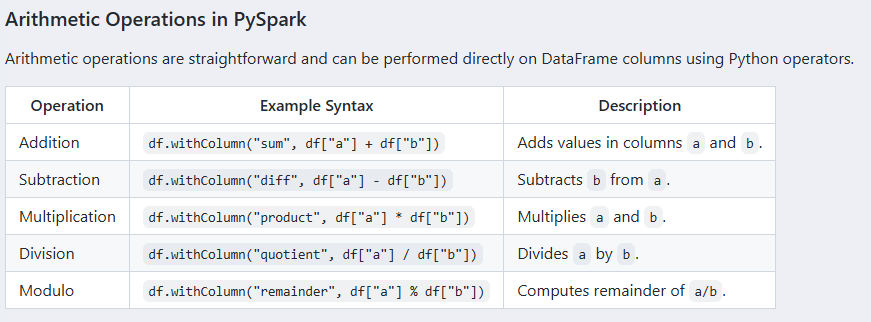

#### Commonly used String functions in Pyspark

1. Basic Operations
    - concat(*cols): Concatenates multiple columns or strings into one.
    - concat_ws(delimiter, *cols): Concatenates columns or strings with a specified delimiter.
2. Substring and Extraction
    - substring(col, pos, length): Extracts a substring from a column.
    - substr(col, pos, length): Alias for substring.
    - regexp_extract(col, pattern, groupIdx): Extracts a match from a - string using a regex pattern.
3. Case Conversion
    - upper(col): Converts text to uppercase.
    - lower(col): Converts text to lowercase.
    - initcap(col): Capitalizes the first letter of each word.

    

In [ ]:
# Converting the nested JSON structure into a flat DataFrame

from pyspark.sql.functions import explode
posts_and_comments_flat = posts_and_comments.select(
    "post_id",
    "user_id",
    explode("comments").alias("comment")
).select(
    "post_id",
    "user_id",
    "comment.*"  # This will flatten the nested structure of comments
)
posts_and_comments_flat.show(5)

+-------+-------+----------+--------------------+-------------------+-------+
|post_id|user_id|comment_id|        comment_text|         created_at|user_id|
+-------+-------+----------+--------------------+-------------------+-------+
|    101|      1|       201|         Great post!|2023-10-01T10:05:00|      2|
|    101|      1|       202|   Very informative.|2023-10-01T10:10:00|      3|
|    102|      2|       203|Absolutely, it's ...|2023-10-02T12:15:00|      1|
|    102|      2|       204| Thanks for sharing!|2023-10-02T12:20:00|      4|
|    103|      3|       205|Congrats! How was...|2023-10-03T09:45:00|      2|
+-------+-------+----------+--------------------+-------------------+-------+
only showing top 5 rows

